# Exame B: Etapa 2 - Testes de Hipótese
## Pedro H. Santos de Castro (202406840014) & Mariana Gonçalves Ribeiro (202406840007)

**Hipóteses analisadas:**
1. `GrLivArea` × `SalePrice`: o preço aumenta com o tamanho? (Pearson / Spearman)
2. `OverallQual` × `SalePrice`: a qualidade geral influencia o preço? (Kruskal-Wallis)
3. `Neighborhood` × `SalePrice`: o preço difere entre bairros? (Kruskal-Wallis)
4. `MoSold` × `SalePrice`: há efeito do mês de venda sobre o preço? (Kruskal-Wallis)
5. `LotFrontage` (ausência) × `LotConfig`: os dados ausentes são aleatórios? (Qui-quadrado de independência)

## Seção 0: Configuração

In [ ]:
# Objetivo: importar bibliotecas e exibir versões (reprodutibilidade)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import scipy.stats as st

RANDOM_STATE = 2025  # seed fixo para operações aleatórias
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

print("pandas:", pd.__version__)
print("numpy :", np.__version__)
print("scipy :", scipy.__version__)

pandas: 2.2.2
numpy : 2.0.2
scipy : 1.16.3


In [ ]:
# Objetivo: clonar repositório com o dataset
!git clone https://github.com/mariribeiro257/estat-exame-B.git

fatal: destination path 'estat-exame-B' already exists and is not an empty directory.


## Seção 1: Tratamento do Dataset

In [ ]:
# Objetivo: carregar o CSV preservando categorias "None" que têm significado real
def load_data(path="estat-exame-B/houses.csv"):
    """Carrega o CSV de casas de Ames.

    Apenas "NA" e strings vazias são tratados como ausentes; o texto "None" é mantido pois, nas colunas em que aparece (ex.: MasVnrType), indica uma categoria com significado ("sem revestimento") e não um dado faltante.

    Parâmetros
    ----------
    path : str
        Caminho para o arquivo houses.csv.

    Retorna
    -------
    pandas.DataFrame
        DataFrame com os dados das casas.
    """
    df = pd.read_csv(path, keep_default_na=False, na_values=["NA", ""])
    return df


houses = load_data()
houses.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
# Objetivo: relatório de dados ausentes
def print_null_info(df):
    """Imprime um relatório das colunas com valores ausentes.

    Parâmetros
    ----------
    df : pandas.DataFrame
        DataFrame a ser inspecionado.
    """
    num_nulls = df.isnull().sum()
    num_nulls = num_nulls[num_nulls > 0].sort_values(ascending=False)

    if num_nulls.empty:
        print("Diagnóstico: não há valores nulos no DataFrame.")
        return

    relatorio = pd.DataFrame({
        "Total de nulos": num_nulls.values,
        "Proporção (%)": (num_nulls.values / len(df) * 100).round(2),
    }, index=num_nulls.index)
    print(relatorio)

print_null_info(houses)

              Total de nulos  Proporção (%)
PoolQC                  1453          99.52
MiscFeature             1406          96.30
Alley                   1369          93.77
Fence                   1179          80.75
FireplaceQu              690          47.26
LotFrontage              259          17.74
GarageCond                81           5.55
GarageType                81           5.55
GarageYrBlt               81           5.55
GarageFinish              81           5.55
GarageQual                81           5.55
BsmtFinType2              38           2.60
BsmtExposure              38           2.60
BsmtCond                  37           2.53
BsmtQual                  37           2.53
BsmtFinType1              37           2.53
MasVnrType                 8           0.55
MasVnrArea                 8           0.55
Electrical                 1           0.07


**Justificativa do tratamento de ausentes.** Nem todo valor ausente significa falta de informação. Nas colunas com maior proporção de nulos (`PoolQC`, `MiscFeature`, `Alley`, `Fence` e `FireplaceQu`), o ausente indica que a casa simplesmente não possui aquela característica (não tem piscina, cerca, etc.). Removê-las ou preencher esses valores introduziria distorção, então elas são mantidas como estão. As variáveis usadas nas hipóteses sobre o preço (`SalePrice`, `OverallQual`, `GrLivArea` e `Neighborhood`) não têm valores ausentes, de modo que esses testes não exigem imputação. A única variável numérica com ausência relevante é `LotFrontage` (259 casos), que não é descartada. Ela é o objeto da Hipótese 5, que investiga se essa ausência ocorre de forma aleatória ou segue algum padrão.

**Estado atual do Dataset.** Confirmação das dimensões e estatísticas de `SalePrice` antes dos testes.

In [ ]:
# Objetivo: relatório final antes dos testes
print("Shape:", houses.shape)
print("\nEstatísticas de SalePrice:")
print(houses["SalePrice"].describe())
print("\nAssimetria (skew) de SalePrice:", round(houses["SalePrice"].skew(), 3))

Shape: (1460, 81)

Estatísticas de SalePrice:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Assimetria (skew) de SalePrice: 1.883


**Distribuição da variável-alvo.** Antes dos testes, vale observar a distribuição de `SalePrice`, que é a variável central de toda a análise. O histograma à esquerda mostra uma forte assimetria à direita: a maioria das casas se concentra em valores mais baixos, com uma cauda de imóveis caros que estende a distribuição. À direita, a transformação logarítmica torna a distribuição bem mais simétrica. Essa assimetria é a principal razão para preferirmos testes não-paramétricos nesta etapa, e antecipa que modelar `log(SalePrice)` em vez do preço bruto tende a melhorar a regressão da Etapa 3.

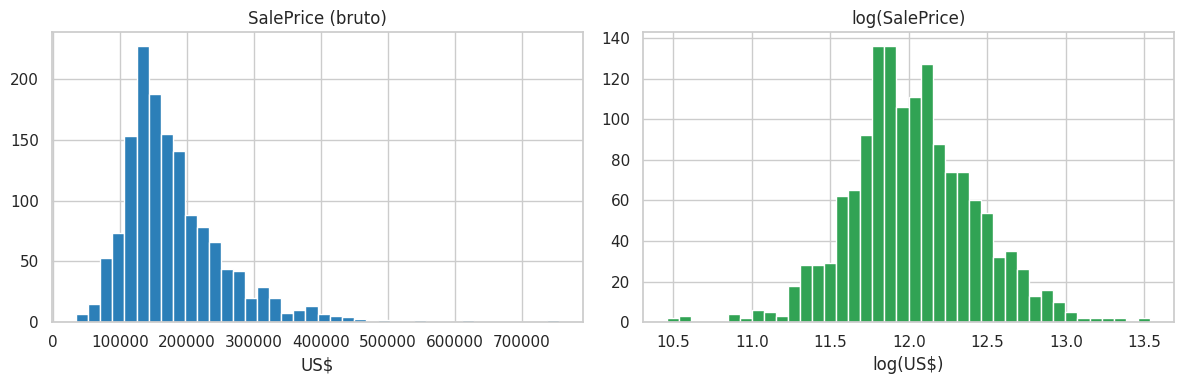

In [ ]:
# Objetivo: visualizar a assimetria de SalePrice (bruto vs. log)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(houses["SalePrice"], bins=40, color="#2c7fb8")
axes[0].set_title("SalePrice (bruto)")
axes[0].set_xlabel("US$")
axes[1].hist(np.log(houses["SalePrice"]), bins=40, color="#31a354")
axes[1].set_title("log(SalePrice)")
axes[1].set_xlabel("log(US$)")
plt.tight_layout()
plt.show()

## Seção 2: Testes de Hipótese

In [ ]:
# Objetivo: lista acumuladora dos resultados (alimenta a tabela-resumo final)
resultados = []
ALPHA = 0.05

### Hipótese 1: `GrLivArea` × `SalePrice` (o preço aumenta com o tamanho?)

**Por que `GrLivArea`?**

Uma vez que a dimensão física do imóvel é, do ponto de vista estrutural e de mercado, um dos principais determinantes do seu valor, o objetivo atual consiste em aplicar testes estatísticos formais para verificar a significância dessa associação. A análise visa confirmar matematicamente se o incremento na área habitável resulta, de fato, em um aumento no preço de venda.

**Hipóteses formuladas:**
- **H₀:** não há correlação entre a área habitável (`GrLivArea`) e o preço (`SalePrice`).
- **H₁:** existe correlação entre `GrLivArea` e `SalePrice`.

**Nível de significância:** α = 0,05, a probabilidade máxima que aceitamos de rejeitar H₀ sendo ela verdadeira (um "falso positivo").

**Testes aplicados:** correlação de **Pearson** e de **Spearman**. Um coeficiente de correlação resume em um único número, entre −1 e +1, o quanto duas variáveis variam juntas. Perto de +1, uma cresce quando a outra cresce. Perto de −1, uma cresce quando a outra diminui. Perto de 0, não há relação clara. O **Pearson** mede a força de uma relação *linear* (quando os pontos se aproximam de uma reta) entre variáveis contínuas, mas pressupõe dados aproximadamente normais e é sensível a valores extremos. O **Spearman** mede uma relação *monotônica*, ou seja, basta que em geral uma variável aumente quando a outra aumenta, mesmo que a curva não seja uma reta. Ele consegue isso porque trabalha com a ordem (a posição) dos valores, e não com os valores brutos, de modo que não depende de normalidade e quase não é afetado por outliers. Aplicar os dois e comparar permite checar se a conclusão se sustenta independentemente dessas suposições.

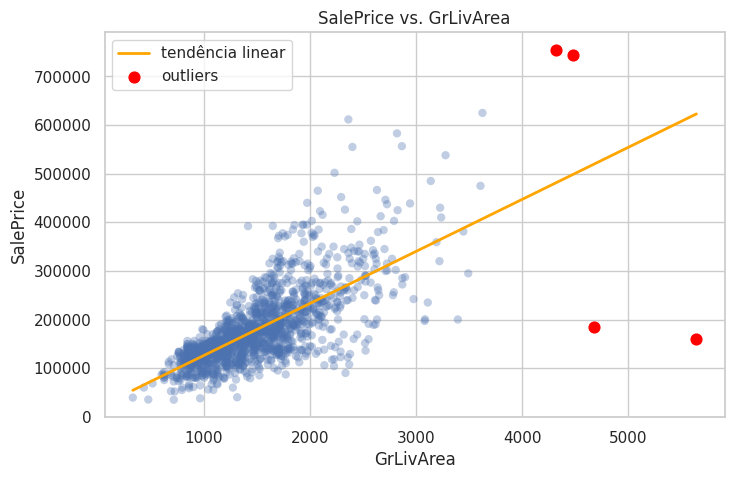

In [ ]:
# Objetivo: função reutilizável de gráfico de dispersão com linha de tendência
def plot_dispersao(df, xcol, ycol, destaque=None):
    """Plota a dispersão entre duas variáveis numéricas com reta de tendência.

    Parâmetros
    ----------
    df : pandas.DataFrame
    xcol, ycol : str
        Nomes das colunas para os eixos x e y.
    destaque : pandas.DataFrame, opcional
        Subconjunto de pontos a destacar em vermelho (ex.: outliers).
    """
    plt.figure(figsize=(8, 5))
    plt.scatter(df[xcol], df[ycol], alpha=0.35, edgecolor="none")
    m, b = np.polyfit(df[xcol], df[ycol], 1)
    xs = np.linspace(df[xcol].min(), df[xcol].max(), 100)
    plt.plot(xs, m * xs + b, color="orange", lw=2, label="tendência linear")
    if destaque is not None:
        plt.scatter(destaque[xcol], destaque[ycol], color="red", s=60,
                    zorder=5, label="outliers")
    plt.xlabel(xcol)
    plt.ylabel(ycol)
    plt.title(f"{ycol} vs. {xcol}")
    plt.legend()
    plt.show()


# Outliers conhecidos do dataset de Ames (casas muito grandes e baratas)
outliers = houses[houses["GrLivArea"] > 4000]
plot_dispersao(houses, "GrLivArea", "SalePrice", destaque=outliers)

**Verificação das suposições.** O Pearson supõe que as variáveis seguem aproximadamente uma distribuição normal e que a relação entre elas é linear. Como `SalePrice` e `GrLivArea` têm assimetria à direita (muitos valores baixos e uma cauda de valores altos), é provável que a normalidade não valha. Para verificar isso de forma objetiva, usamos o teste de **Shapiro-Wilk**, cuja hipótese nula é "os dados vêm de uma distribuição normal". Assim, um p-valor abaixo de 0,05 é evidência de que os dados **não** são normais.

In [ ]:
# Objetivo: checar normalidade (suposição do Pearson) via Shapiro-Wilk
for col in ["GrLivArea", "SalePrice"]:
    stat, p = st.shapiro(houses[col])
    print(f"{col:10} | Shapiro W={stat:.4f} | p={p:.2e} | "
          f"assimetria={houses[col].skew():.3f}")

GrLivArea  | Shapiro W=0.9280 | p=6.60e-26 | assimetria=1.367
SalePrice  | Shapiro W=0.8697 | p=3.21e-33 | assimetria=1.883


**Justificativa da escolha do teste.** Se o Shapiro-Wilk rejeita a normalidade (p < 0,05), a suposição exigida pelo Pearson deixa de valer. O coeficiente ainda pode ser calculado, mas seu p-valor fica menos confiável. Para não depender dessa suposição, reportamos também o Spearman. Se os dois testes apontarem a mesma direção e uma força parecida, ganhamos confiança na conclusão. Uma ressalva importante: em amostras grandes como esta (n = 1460), o Shapiro-Wilk costuma rejeitar a normalidade mesmo quando os desvios são pequenos e sem impacto prático, porque com muitos dados o teste detecta até diferenças mínimas. Por isso não decidimos apenas pelo p-valor, mas também olhando a assimetria e os gráficos.

In [ ]:
# Objetivo: calcular Pearson e Spearman entre GrLivArea e SalePrice
def analisar_correlacao(x, y):
    """Calcula correlações de Pearson e Spearman entre dois vetores.

    Parâmetros
    ----------
    x, y : array-like

    Retorna
    -------
    dict
        Chaves: pearson_r, pearson_p, spearman_r, spearman_p.
    """
    r_p, p_p = st.pearsonr(x, y)
    r_s, p_s = st.spearmanr(x, y)
    return {"pearson_r": r_p, "pearson_p": p_p,
            "spearman_r": r_s, "spearman_p": p_s}


cor = analisar_correlacao(houses["GrLivArea"], houses["SalePrice"])
print(f"Pearson : r = {cor['pearson_r']:.4f} | p = {cor['pearson_p']:.2e}")
print(f"Spearman: rho = {cor['spearman_r']:.4f} | p = {cor['spearman_p']:.2e}")

resultados.append({
    "Hipótese": "H1: GrLivArea x SalePrice",
    "Resumo": "O preço de venda aumenta com a área habitável",
    "Teste": "Pearson / Spearman",
    "Estatística": f"r={cor['pearson_r']:.3f}; rho={cor['spearman_r']:.3f}",
    "p-valor": f"{cor['pearson_p']:.1e}",
    "Tamanho de efeito": f"r={cor['pearson_r']:.2f} (forte)",
    "Decisão (alfa=0,05)": "Rejeita H0" if cor["pearson_p"] < ALPHA else "Não rejeita H0",
})

Pearson : r = 0.7086 | p = 4.52e-223
Spearman: rho = 0.7313 | p = 1.43e-244


**Resultados:**

| Item | Valor |
|------|-------|
| Teste aplicado | Correlação de Pearson e de Spearman |
| Nível de significância (α) | 0,05 |
| Coeficiente de Pearson (r) | ≈ 0,709 |
| p-valor (Pearson) | < 0,001 |
| Coeficiente de Spearman (ρ) | ≈ 0,731 |
| p-valor (Spearman) | < 0,001 |
| Tamanho de efeito | r ≈ 0,71 (forte) |
| Tamanho da amostra (n) | 1460 |
| Decisão | Rejeita H₀ |

**Conclusão.** Os dois coeficientes deram altos e positivos (r ≈ 0,709 no Pearson e ρ ≈ 0,731 no Spearman). Como referência, correlações em torno de 0,7 são consideradas fortes. Ambos os p-valores ficaram muito abaixo de 0,05, então **rejeitamos H₀**: existe correlação positiva e forte entre a área habitável e o preço, ou seja, quanto maior a casa, maior tende a ser o valor de venda. O fato de Pearson e Spearman chegarem a valores próximos mostra que a relação é robusta e não foi criada nem mascarada pelos outliers (as casas grandes e baratas em vermelho no gráfico, que são vendas atípicas). Na prática, isso confirma `GrLivArea` como uma das variáveis mais promissoras para o modelo de regressão da Etapa 3.

### Hipótese 2: `OverallQual` × `SalePrice` (a qualidade influencia o preço?)

**Por que `OverallQual`?**

Durante a análise exploratória (Etapa 1), analisamos as principais variáveis ordinais do conjunto de dados, contrastando os indicadores de Qualidade com os indicadores de Condição dos imóveis. Observamos que as variáveis de Qualidade apresentavam uma correlação de Spearman mais forte com a variável `SalePrice` do que as variáveis de Condição. Neste contexto, a variável `OverallQual` destacou-se por apresentar o coeficiente de correlação de Spearman mais elevado. O objetivo atual consiste em testar a significância estatística desta relação.

**Hipóteses formuladas:**
- **H₀:** a distribuição de `SalePrice` é igual entre os níveis de `OverallQual`.
- **H₁:** ao menos um nível de `OverallQual` tem distribuição de `SalePrice` diferente.

**Nível de significância:** α = 0,05

**Teste aplicado:** **Kruskal-Wallis**. Aqui `OverallQual` separa as casas em dez grupos (notas de qualidade de 1 a 10) e queremos saber se o preço difere entre eles. O teste clássico para comparar três ou mais grupos é a **ANOVA**, mas ela exige duas condições: que os dados de cada grupo sejam aproximadamente normais e que os grupos tenham variâncias parecidas. Como `OverallQual` é ordinal e `SalePrice` é assimétrico, é provável que essas condições não valham. O **Kruskal-Wallis** é a versão não-paramétrica da ANOVA. Em vez de comparar médias, ele ordena todos os valores e compara a posição média (os *postos*) de cada grupo, o que dispensa a normalidade. Verificamos essas condições a seguir e, como elas não se sustentam, o Kruskal-Wallis é a escolha adequada.

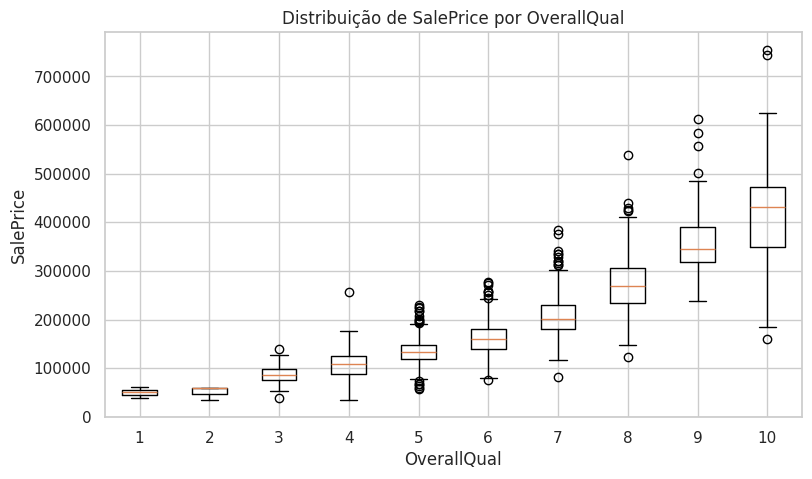

In [ ]:
# Objetivo: Plotar boxplot de SalePrice em relação aos grupos de OverallQual
def plot_boxplot_por_grupo(df, grupo, valor):
    """Boxplot de `valor` segmentado pelos níveis de `grupo`.

    Parâmetros
    ----------
    df : pandas.DataFrame
    grupo : str
        Coluna categórica/ordinal usada no eixo x.
    valor : str
        Coluna numérica usada no eixo y.
    """
    niveis = sorted(df[grupo].dropna().unique())
    dados = [df[df[grupo] == n][valor].values for n in niveis]
    plt.figure(figsize=(9, 5))
    plt.boxplot(dados)
    plt.xticks(range(1, len(niveis) + 1), niveis)
    plt.xlabel(grupo)
    plt.ylabel(valor)
    plt.title(f"Distribuição de {valor} por {grupo}")
    plt.show()


plot_boxplot_por_grupo(houses, "OverallQual", "SalePrice")

**Verificação das suposições.** Para decidir com segurança entre ANOVA e Kruskal-Wallis, testamos as duas condições da ANOVA. A primeira é a **normalidade dentro de cada grupo**, verificada com o Shapiro-Wilk aplicado a cada nível de qualidade. A segunda é a **homogeneidade das variâncias** (ou homocedasticidade), isto é, se a dispersão dos preços é parecida entre os grupos. Para isso usamos o teste de **Levene**, cuja hipótese nula é "as variâncias são iguais", então um p < 0,05 indica que elas diferem.

In [ ]:
# Objetivo: testar suposições da ANOVA (Shapiro por grupo e Levene)
def checar_suposicoes_grupos(df, grupo, valor):
    """Verifica normalidade (Shapiro por grupo) e homocedasticidade (Levene).

    Parâmetros
    ----------
    df : pandas.DataFrame
    grupo, valor : str

    Retorna
    -------
    tuple
        (p_levene, dict de p-valores de Shapiro por nível).
    """
    niveis = sorted(df[grupo].dropna().unique())
    amostras = [df[df[grupo] == n][valor].values for n in niveis]
    shapiro_p = {}
    for n, a in zip(niveis, amostras):
        if len(a) >= 3:  # Shapiro exige n >= 3
            shapiro_p[n] = st.shapiro(a).pvalue
    stat_lev, p_lev = st.levene(*amostras)
    return p_lev, shapiro_p


p_levene, shapiro_p = checar_suposicoes_grupos(houses, "OverallQual", "SalePrice")
n_nao_normais = sum(1 for p in shapiro_p.values() if p < ALPHA)
print(f"Levene (H0: variâncias iguais): p = {p_levene:.2e}")
print(f"Grupos que rejeitam normalidade (Shapiro p<0,05): "
      f"{n_nao_normais} de {len(shapiro_p)}")

Levene (H0: variâncias iguais): p = 2.81e-53
Grupos que rejeitam normalidade (Shapiro p<0,05): 7 de 9


**Justificativa da escolha do teste.** O Levene deu p < 0,05, ou seja, as variâncias diferem de forma significativa entre os grupos, o que também se vê no boxplot, em que as caixas ficam cada vez mais altas nas notas maiores. O Shapiro-Wilk, por sua vez, rejeitou a normalidade na maioria dos níveis. Com as duas condições da ANOVA violadas, seus resultados seriam pouco confiáveis para estes dados, e por isso adotamos o Kruskal-Wallis, que não exige nenhuma das duas. Vale a mesma ressalva da Hipótese 1: em amostras grandes os testes de suposição rejeitam com facilidade, mas aqui tanto a assimetria de `SalePrice` quanto a diferença visível de dispersão entre os grupos confirmam que a escolha não-paramétrica é a mais apropriada.

In [ ]:
# Objetivo: aplicar Kruskal-Wallis e calcular o tamanho de efeito
def testar_kruskal(df, grupo, valor):
    """Executa o teste de Kruskal-Wallis de `valor` entre níveis de `grupo`.

    Parâmetros
    ----------
    df : pandas.DataFrame
    grupo, valor : str

    Retorna
    -------
    tuple
        (estatística H, p-valor).
    """
    niveis = sorted(df[grupo].dropna().unique())
    amostras = [df[df[grupo] == n][valor].values for n in niveis]
    return st.kruskal(*amostras)


def epsilon_quadrado(H, n):
    """Tamanho de efeito ε² do Kruskal-Wallis: ε² = H / (n - 1).

    Varia de 0 a 1. Referência (Cohen): ~0,01 pequeno, ~0,06 médio, ~0,14 grande.

    Parâmetros
    ----------
    H : float
        Estatística H do teste.
    n : int
        Número total de observações.

    Retorna
    -------
    float
        Valor de ε².
    """
    return H / (n - 1)


H, p = testar_kruskal(houses, "OverallQual", "SalePrice")
eps = epsilon_quadrado(H, len(houses))
print(f"Kruskal-Wallis: H = {H:.2f} | p = {p:.2e} | ε² = {eps:.3f}")

resultados.append({
    "Hipótese": "H2: OverallQual x SalePrice",
    "Resumo": "A qualidade geral influencia o preço de venda",
    "Teste": "Kruskal-Wallis",
    "Estatística": f"H={H:.1f}",
    "p-valor": f"{p:.1e}",
    "Tamanho de efeito": f"ε²={eps:.2f} (grande)",
    "Decisão (alfa=0,05)": "Rejeita H0" if p < ALPHA else "Não rejeita H0",
})

Kruskal-Wallis: H = 966.10 | p = 3.51e-202 | ε² = 0.662


**Resultados:**

| Item | Valor |
|------|-------|
| Teste aplicado | Kruskal-Wallis |
| Nível de significância (α) | 0,05 |
| Número de grupos | 10 (notas de 1 a 10) |
| Estatística H | ≈ 966,1 |
| Graus de liberdade | 9 |
| p-valor | < 0,001 |
| Tamanho de efeito (ε²) | ≈ 0,66 (grande) |
| Tamanho da amostra (n) | 1460 |
| Decisão | Rejeita H₀ |

**Conclusão.** O p-valor ficou muito abaixo de 0,05, então **rejeitamos H₀**: a distribuição de preços não é igual entre os níveis de qualidade. Mas a significância sozinha não diz o tamanho da diferença, e por isso reportamos também o **tamanho de efeito** ε² (épsilon-quadrado), que varia de 0 a 1 e indica que proporção da variação nos postos de preço é explicada pela qualidade. Quanto mais perto de 1, mais forte a associação (como referência, valores acima de 0,14 já são considerados grandes). Aqui ε² ≈ 0,66, um efeito grande: a qualidade explica boa parte da variação no preço, não é só uma diferença estatisticamente detectável. Esse cuidado importa porque, com uma amostra grande, quase qualquer diferença apareceria como significativa, e o ε² mostra que o efeito é de fato relevante. Concretamente, a mediana de `SalePrice` sobe de forma contínua com a qualidade, de cerca de US\$ 50 mil (nota 1) a US\$ 432 mil (nota 10). `OverallQual` é, portanto, uma das preditoras mais importantes para a Etapa 3.

### Hipótese 3: `Neighborhood` × `SalePrice` (o preço difere entre bairros?)

**Por que `Neighborhood`?**

A variável de bairros das casas do dataset também foi foco durante a análise exploratória (Etapa 1). De maneira intuitiva, pressupõe-se que a localização geográfica do imóvel reflita diferentes perfis socioeconômicos, resultando em variações em seu valor de mercado. Embora os gráficos gerados anteriormente sugiram essa associação, verificaremos agora efetivamente se existe significância estatística que comprove a diferença do preço de venda (`SalePrice`) entre os diferentes bairros de Ames.

**Hipóteses formuladas:**
- **H₀:** a distribuição de `SalePrice` é igual entre todos os bairros.
- **H₁:** ao menos um bairro tem distribuição de `SalePrice` diferente.

**Nível de significância:** α = 0,05

**Teste aplicado:** **Kruskal-Wallis**, pela mesma razão da Hipótese 2. A diferença é que agora há 25 grupos (os bairros), em vez de 10. `SalePrice` continua assimétrico e alguns bairros têm poucas casas, condições em que a ANOVA não é confiável. Por trabalhar com a ordem dos valores (os postos), o Kruskal-Wallis compara as distribuições de preço entre os bairros sem exigir normalidade nem variâncias iguais.

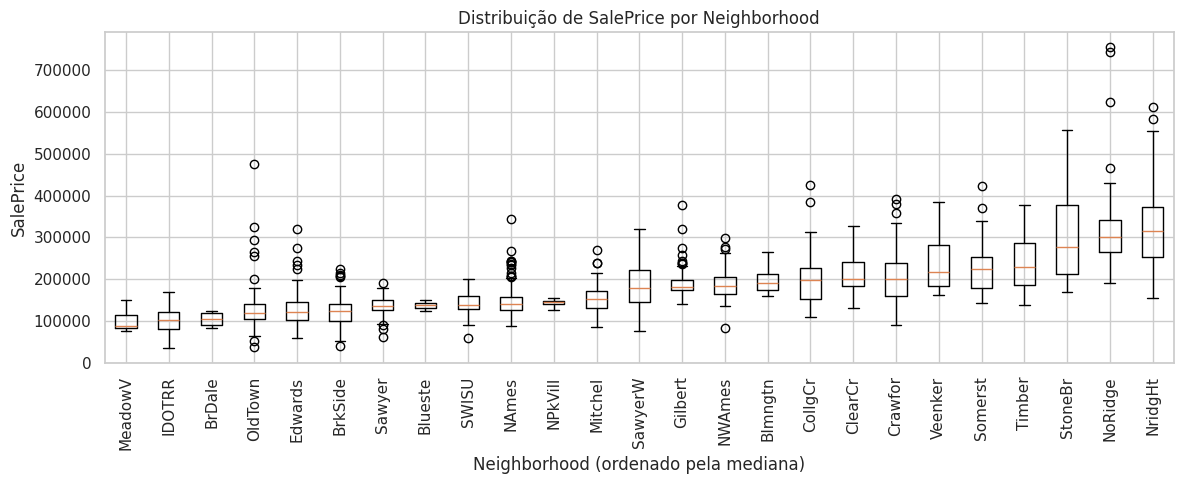

In [ ]:
# Objetivo: boxplot dos bairros ordenados pela mediana (legibilidade com 25 grupos)
def plot_boxplot_ordenado(df, grupo, valor):
    """Boxplot de `valor` por `grupo`, ordenado pela mediana, com rótulos girados.

    Indicado quando há muitas categorias (ex.: bairros).

    Parâmetros
    ----------
    df : pandas.DataFrame
    grupo, valor : str
    """
    ordem = df.groupby(grupo)[valor].median().sort_values().index
    dados = [df[df[grupo] == n][valor].values for n in ordem]
    plt.figure(figsize=(12, 5))
    plt.boxplot(dados)
    plt.xticks(range(1, len(ordem) + 1), ordem, rotation=90)
    plt.xlabel(f"{grupo} (ordenado pela mediana)")
    plt.ylabel(valor)
    plt.title(f"Distribuição de {valor} por {grupo}")
    plt.tight_layout()
    plt.show()


plot_boxplot_ordenado(houses, "Neighborhood", "SalePrice")

**Verificação das suposições.** Reaproveitamos a função `checar_suposicoes_grupos`, criada na Hipótese 2, que aplica o Shapiro-Wilk a cada bairro e o teste de Levene ao conjunto, evitando repetir código. Como nas hipóteses anteriores, espera-se que a normalidade e a igualdade de variâncias sejam rejeitadas, o que reforça a escolha do Kruskal-Wallis.

In [ ]:
# Objetivo: verificar suposições (reuso da função da H2)
p_levene, shapiro_p = checar_suposicoes_grupos(houses, "Neighborhood", "SalePrice")
n_nao_normais = sum(1 for p in shapiro_p.values() if p < ALPHA)
print(f"Levene (H0: variâncias iguais): p = {p_levene:.2e}")
print(f"Bairros que rejeitam normalidade (Shapiro p<0,05): "
      f"{n_nao_normais} de {len(shapiro_p)}")

Levene (H0: variâncias iguais): p = 3.36e-43
Bairros que rejeitam normalidade (Shapiro p<0,05): 14 de 24


In [ ]:
# Objetivo: aplicar Kruskal-Wallis entre os bairros e calcular o efeito (reuso da H2)
H, p = testar_kruskal(houses, "Neighborhood", "SalePrice")
eps = epsilon_quadrado(H, len(houses))
print(f"Kruskal-Wallis: H = {H:.1f} | p = {p:.2e} | ε² = {eps:.3f}")

resultados.append({
    "Hipótese": "H3: Neighborhood x SalePrice",
    "Resumo": "O preço de venda difere entre os bairros",
    "Teste": "Kruskal-Wallis",
    "Estatística": f"H={H:.1f}",
    "p-valor": f"{p:.1e}",
    "Tamanho de efeito": f"ε²={eps:.2f} (grande)",
    "Decisão (alfa=0,05)": "Rejeita H0" if p < ALPHA else "Não rejeita H0",
})

Kruskal-Wallis: H = 868.5 | p = 6.70e-168 | ε² = 0.595


**Resultados.**

| Item | Valor |
|------|-------|
| Teste aplicado | Kruskal-Wallis |
| Nível de significância (α) | 0,05 |
| Número de grupos | 25 (bairros) |
| Estatística H | ≈ 868,5 |
| Graus de liberdade | 24 |
| p-valor | < 0,001 |
| Tamanho de efeito (ε²) | ≈ 0,60 (grande) |
| Tamanho da amostra (n) | 1460 |
| Decisão | Rejeita H₀ |

**Conclusão.** O p-valor ficou muito abaixo de 0,05 e o tamanho de efeito é grande (ε² ≈ 0,60), então **rejeitamos H₀**, e a diferença de preço entre bairros é não só significativa como expressiva. Para dar uma ideia concreta, a mediana de preço vai de cerca de US\$ 88 mil no bairro mais barato (MeadowV) a US\$ 315 mil no mais caro (NridgHt), uma razão de 3,6 vezes. Isso confirma a localização como fator determinante do preço e indica que `Neighborhood` deve entrar como variável categórica no modelo da Etapa 3. Uma observação útil para a modelagem: como cada bairro tende a reunir casas de qualidade, tamanho e padrão construtivo parecidos, parte da informação do bairro pode se repetir na de outras variáveis (por exemplo, `OverallQual`). Essa sobreposição pode atrapalhar a regressão e deve ser avaliada na próxima etapa.

### Hipótese 4: `MoSold` × `SalePrice` (o mês da venda afeta o preço?)

**Por que `MoSold`?**

Na análise de mercados imobiliários, a sazonalidade é frequentemente apontada como um fator de influência na dinâmica de oferta e demanda. A variável `MoSold` indica o mês exato em que a transação do imóvel foi feita. Existe uma premissa teórica de que determinadas épocas do ano (como a primavera ou o verão) podem impulsionar o mercado, resultando em potenciais variações nos valores. Iremos, então, aplicar testes estatísticos para determinar se o preço de venda (`SalePrice`) apresenta diferenças significativas entre os doze meses do ano, atestando ou descartando a existência de um efeito sazonal sobre os preços na cidade de Ames.

**Hipóteses formuladas:**
- **H₀:** a distribuição de `SalePrice` é igual entre os doze meses de venda.
- **H₁:** ao menos um mês tem distribuição de `SalePrice` diferente.

**Nível de significância:** α = 0,05

**Teste aplicado:** **Kruskal-Wallis**, pela mesma razão das hipóteses anteriores. `MoSold` separa as vendas em doze grupos (os meses) e o preço continua assimétrico, então usamos o teste por postos, que não exige normalidade nem variâncias iguais. Vale separar duas perguntas que costumam se confundir: aqui não testamos se vendem mais casas em certos meses (volume), e sim se as casas vendidas em certos meses custam mais (preço). O teste se aplica apenas ao preço.

**Observação sobre o agrupamento.** O dataset cobre vendas de 2006 a 2010. Ao agrupar por `MoSold`, reunimos em cada grupo todas as casas vendidas naquele mês do calendário ao longo de todos os anos. Por exemplo, o grupo de janeiro contém as 58 casas vendidas em janeiro somando os cinco anos. A comparação é, portanto, entre meses do ano, sem separar por ano de venda.

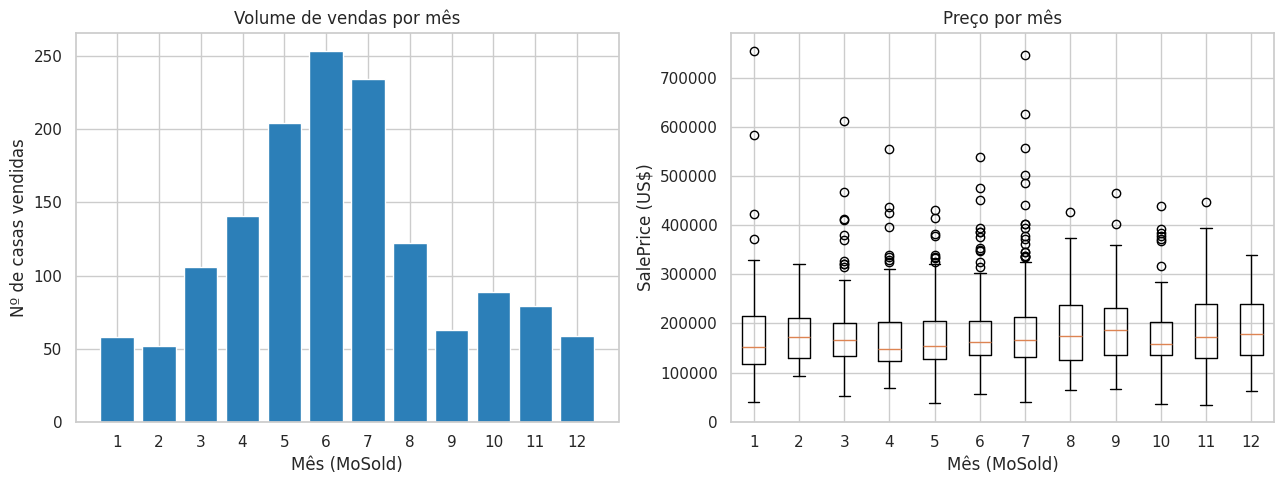

In [ ]:
# Objetivo: contrastar o volume de vendas (sazonal) com o preço por mês
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Painel esquerdo: quantas casas vendem por mês (volume)
contagem = houses["MoSold"].value_counts().sort_index()
axes[0].bar(contagem.index, contagem.values, color="#2c7fb8")
axes[0].set_title("Volume de vendas por mês")
axes[0].set_xlabel("Mês (MoSold)")
axes[0].set_ylabel("Nº de casas vendidas")
axes[0].set_xticks(range(1, 13))

# Painel direito: distribuição de preço por mês
dados = [houses[houses["MoSold"] == m]["SalePrice"].values for m in range(1, 13)]
axes[1].boxplot(dados)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(range(1, 13))
axes[1].set_title("Preço por mês")
axes[1].set_xlabel("Mês (MoSold)")
axes[1].set_ylabel("SalePrice (US$)")

plt.tight_layout()
plt.show()

**Verificação das suposições.** Como nas Hipóteses 2 e 3, aplicamos `checar_suposicoes_grupos` para confirmar que a normalidade e a igualdade de variâncias não se sustentam, o que mantém o Kruskal-Wallis como teste adequado.

In [ ]:
# Objetivo: verificar suposições da ANOVA (reuso da função da H2)
p_levene, shapiro_p = checar_suposicoes_grupos(houses, "MoSold", "SalePrice")
n_nao_normais = sum(1 for p in shapiro_p.values() if p < ALPHA)
print(f"Levene (H0: variâncias iguais): p = {p_levene:.3f}")
print(f"Meses que rejeitam normalidade (Shapiro p<0,05): "
      f"{n_nao_normais} de {len(shapiro_p)}")

Levene (H0: variâncias iguais): p = 0.085
Meses que rejeitam normalidade (Shapiro p<0,05): 11 de 12


In [ ]:
# Objetivo: aplicar Kruskal-Wallis entre os meses e calcular o efeito
H, p = testar_kruskal(houses, "MoSold", "SalePrice")
eps = epsilon_quadrado(H, len(houses))
print(f"Kruskal-Wallis: H = {H:.2f} | p = {p:.3f} | ε² = {eps:.4f}")

resultados.append({
    "Hipótese": "H4: MoSold x SalePrice",
    "Resumo": "O mês da venda influencia o preço de venda",
    "Teste": "Kruskal-Wallis",
    "Estatística": f"H={H:.1f}",
    "p-valor": f"{p:.3f}",
    "Tamanho de efeito": f"ε²={eps:.3f} (desprezível)",
    "Decisão (alfa=0,05)": "Rejeita H0" if p < ALPHA else "Não rejeita H0",
})

Kruskal-Wallis: H = 14.28 | p = 0.218 | ε² = 0.0098


**Resultados.**

| Item | Valor |
|------|-------|
| Teste aplicado | Kruskal-Wallis |
| Nível de significância (α) | 0,05 |
| Número de grupos | 12 (meses) |
| Estatística H | ≈ 14,3 |
| Graus de liberdade | 11 |
| p-valor | ≈ 0,22 |
| Tamanho de efeito (ε²) | ≈ 0,01 (desprezível) |
| Tamanho da amostra (n) | 1460 |
| Decisão | Não rejeita H₀ |

**Conclusão.** O p-valor (≈ 0,22) ficou acima de 0,05, então **não rejeitamos H₀**. Não há evidência de que o preço varie conforme o mês da venda. O tamanho de efeito reforça essa leitura, pois ε² ≈ 0,01 é praticamente nulo, indicando que o mês explica quase nada da variação no preço. Esse resultado não significa que o mês seja irrelevante para o mercado. O gráfico da esquerda mostra forte sazonalidade no volume de vendas, com pico entre maio e julho e fundo no inverno, mas o gráfico da direita mostra medianas de preço quase planas ao longo do ano. Em outras palavras, vende-se mais casas na primavera e no verão, porém não por preços maiores. Para a Etapa 3, isso indica que `MoSold` provavelmente não é um bom preditor de preço e pode ficar de fora do modelo, decisão que esta hipótese ajuda a fundamentar.

### Hipótese 5: ausência de `LotFrontage` × `LotConfig` (os dados ausentes são aleatórios?)

**Por que `LotFrontage` e `LotConfig`?**

A variável `LotFrontage` (a medida da frente do lote) tem 259 valores ausentes. Antes de decidir como preencher esses valores na Etapa 3, é importante saber se eles somem ao acaso ou se a ausência segue algum padrão. Esta hipótese investiga isso.

**Hipóteses formuladas:**
- **H₀:** a ausência de `LotFrontage` é independente do tipo de lote (`LotConfig`).
- **H₁:** a ausência de `LotFrontage` depende do tipo de lote.

**Nível de significância:** α = 0,05

**Teste aplicado:** **qui-quadrado de independência**. Diferente das hipóteses anteriores, aqui as duas variáveis são categóricas. A primeira é se o valor está ausente ou presente, e a segunda é o tipo de lote. O teste monta uma tabela de contingência (a contagem de casas em cada cruzamento) e compara o que foi observado com o que seria esperado caso as duas variáveis fossem independentes. Quanto maior a diferença entre observado e esperado, mais forte a evidência de que existe relação.

**Justificativa do agrupamento de categorias.** O qui-quadrado supõe que pelo menos 80% das células tenham frequência esperada maior ou igual a 5. A categoria `FR3` (frente em três lados) tem apenas 4 casas no dataset, o que gera células com esperado abaixo de 5 e viola essa premissa. Como `FR2` e `FR3` representam ideias parecidas (frente em dois ou três lados do lote), nós as reunimos em uma única categoria chamada `FR2e3`. Depois desse agrupamento todas as frequências esperadas ficam acima de 5 e o teste passa a ser válido.

In [ ]:
# Objetivo: criar o indicador de ausência e agrupar a categoria rara FR3
houses["LotFront_ausente"] = np.where(houses["LotFrontage"].isna(),
                                       "Ausente", "Presente")
houses["LotConfigAgr"] = houses["LotConfig"].replace({"FR3": "FR2e3",
                                                       "FR2": "FR2e3"})

# Tabela de contingência e proporção de ausência por tipo de lote
tabela = pd.crosstab(houses["LotConfigAgr"], houses["LotFront_ausente"])
print("Tabela de contingência (observado):")
print(tabela)

prop_ausente = (houses.groupby("LotConfigAgr")["LotFront_ausente"]
                .apply(lambda s: (s == "Ausente").mean() * 100).round(1))
print("\n% de LotFrontage ausente por tipo de lote:")
print(prop_ausente)

Tabela de contingência (observado):
LotFront_ausente  Ausente  Presente
LotConfigAgr                       
Corner                 62       201
CulDSac                49        45
FR2e3                  14        37
Inside                134       918

% de LotFrontage ausente por tipo de lote:
LotConfigAgr
Corner     23.6
CulDSac    52.1
FR2e3      27.5
Inside     12.7
Name: LotFront_ausente, dtype: float64


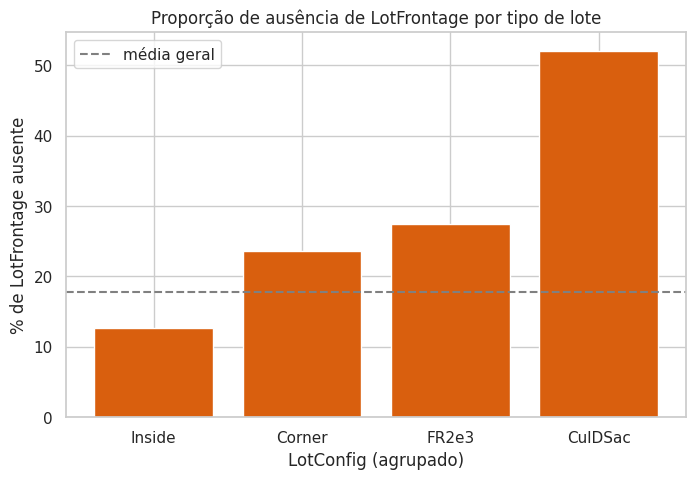

In [ ]:
# Objetivo: visualizar a proporção de ausência por tipo de lote
prop = prop_ausente.sort_values()
plt.figure(figsize=(8, 5))
plt.bar(prop.index, prop.values, color="#d95f0e")
plt.axhline(houses["LotFrontage"].isna().mean() * 100, color="gray",
            linestyle="--", label="média geral")
plt.ylabel("% de LotFrontage ausente")
plt.xlabel("LotConfig (agrupado)")
plt.title("Proporção de ausência de LotFrontage por tipo de lote")
plt.legend()
plt.show()

**Verificação das suposições.** Abaixo conferimos se todas as frequências esperadas ficaram maiores ou iguais a 5, condição para o qui-quadrado ser confiável. Reportamos também o V de Cramér, uma medida de tamanho de efeito para tabelas de contingência que varia de 0 (sem associação) a 1 (associação perfeita).

In [ ]:
# Objetivo: aplicar o qui-quadrado de independência e medir o efeito
def testar_qui_quadrado(df, linha, coluna):
    """Qui-quadrado de independência entre duas variáveis categóricas.

    Parâmetros
    ----------
    df : pandas.DataFrame
    linha, coluna : str
        Nomes das duas variáveis categóricas.

    Retorna
    -------
    tuple
        (chi2, p-valor, graus de liberdade, frequências esperadas,
         V de Cramér).
    """
    tab = pd.crosstab(df[linha], df[coluna])
    chi2, p, dof, esperadas = st.chi2_contingency(tab)
    n = tab.values.sum()
    v_cramer = np.sqrt(chi2 / (n * (min(tab.shape) - 1)))
    return chi2, p, dof, esperadas, v_cramer


chi2, p, dof, esperadas, v_cramer = testar_qui_quadrado(
    houses, "LotConfigAgr", "LotFront_ausente")
print(f"Qui-quadrado = {chi2:.2f} | gl = {dof} | p = {p:.2e}")
print(f"Menor frequência esperada = {esperadas.min():.1f} (premissa: >= 5)")
print(f"V de Cramér = {v_cramer:.3f}")

resultados.append({
    "Hipótese": "H5: LotFrontage ausente x LotConfig",
    "Resumo": "A ausência de LotFrontage depende do tipo de lote",
    "Teste": "Qui-quadrado de independência",
    "Estatística": f"chi2={chi2:.1f}",
    "p-valor": f"{p:.1e}",
    "Tamanho de efeito": f"V de Cramér={v_cramer:.2f} (moderado)",
    "Decisão (alfa=0,05)": "Rejeita H0" if p < ALPHA else "Não rejeita H0",
})

Qui-quadrado = 103.64 | gl = 3 | p = 2.56e-22
Menor frequência esperada = 9.0 (premissa: >= 5)
V de Cramér = 0.266


**Resultados.**

| Item | Valor |
|------|-------|
| Teste aplicado | Qui-quadrado de independência |
| Nível de significância (α) | 0,05 |
| Estatística χ² | ≈ 103,6 |
| Graus de liberdade | 3 |
| p-valor | < 0,001 |
| Menor frequência esperada | 9,0 (premissa atendida) |
| Tamanho de efeito (V de Cramér) | ≈ 0,27 (moderado) |
| Tamanho da amostra (n) | 1460 |
| Decisão | Rejeita H₀ |

**Conclusão.** O p-valor ficou muito abaixo de 0,05, então **rejeitamos H₀**. A ausência de `LotFrontage` não é aleatória, ela depende do tipo de lote. O padrão fica claro no gráfico, pois lotes em rua sem saída (`CulDSac`) têm cerca de 52% de ausência e os de esquina (`Corner`) 24%, contra apenas 13% dos lotes internos (`Inside`). Isso faz sentido na prática, já que lotes irregulares ou de esquina têm uma frente de difícil definição, o que explica o dado faltar mais nesses casos. O V de Cramér de 0,27 indica uma associação de força moderada.

**Importância para a Etapa 3.** Este resultado tem efeito prático direto sobre o modelo de regressão. Na Etapa 3 será preciso decidir o que fazer com os 259 valores ausentes de `LotFrontage`, porque um modelo de regressão não aceita dados faltantes. A solução mais comum é preencher esses vazios com a média ou a mediana geral da coluna, mas isso só é correto quando os valores somem ao acaso. A H5 mostrou que não é o caso aqui, pois a ausência depende do tipo de lote. Preencher tudo com um único valor médio ignoraria esse padrão e introduziria viés, por exemplo ao atribuir a um lote em rua sem saída uma frente típica de lote interno. O caminho mais adequado é imputar por grupo, usando a mediana de `LotFrontage` dentro de cada bairro ou tipo de lote, ou então criar uma variável indicadora que marque quais casas tinham o dado ausente, preservando a informação que o próprio fato de estar ausente carrega. Em resumo, a H5 transforma uma decisão que costuma ser tomada no automático em uma escolha fundamentada, o que tende a melhorar a qualidade do modelo.

## Seção 3: Conclusão

**Consolidação dos cinco testes realizados.** A tabela reúne, para cada hipótese, o teste aplicado, a estatística, o p-valor, o tamanho de efeito e a decisão sobre H₀ ao nível de significância α = 0,05.

In [ ]:
tabela_resumo = pd.DataFrame(resultados)

(tabela_resumo.style
    .hide(axis="index")
    .set_properties(**{"text-align": "left", "font-size": "13px", "padding": "8px"})
    .set_table_styles([
        {"selector": "th",
         "props": [("background-color", "#37474f"), ("color", "white"),
                   ("text-align", "left"), ("padding", "8px")]}
    ])
    .set_caption("Tabela-resumo das hipóteses")
)

Hipótese,Resumo,Teste,Estatística,p-valor,Tamanho de efeito,"Decisão (alfa=0,05)"
H1: GrLivArea x SalePrice,O preço de venda aumenta com a área habitável,Pearson / Spearman,r=0.709; rho=0.731,4.5e-223,r=0.71 (forte),Rejeita H0
H2: OverallQual x SalePrice,A qualidade geral influencia o preço de venda,Kruskal-Wallis,H=966.1,3.5e-202,ε²=0.66 (grande),Rejeita H0
H3: Neighborhood x SalePrice,O preço de venda difere entre os bairros,Kruskal-Wallis,H=868.5,6.7e-168,ε²=0.60 (grande),Rejeita H0
H4: MoSold x SalePrice,O mês da venda influencia o preço de venda,Kruskal-Wallis,H=14.3,0.218,ε²=0.010 (desprezível),Não rejeita H0
H5: LotFrontage ausente x LotConfig,A ausência de LotFrontage depende do tipo de lote,Qui-quadrado de independência,chi2=103.6,2.6e-22,V de Cramér=0.27 (moderado),Rejeita H0


**Os cinco testes mostraram com clareza o que está associado ao preço das casas em Ames, e isso orienta a Etapa 3.**

Três variáveis se confirmaram como fortes preditoras. O tamanho (GrLivArea) tem correlação positiva forte. A qualidade geral (OverallQual) apresentou um dos maiores efeitos da análise. E o bairro (Neighborhood) mostrou medianas variando até 3,6 vezes. As três devem entrar no modelo.  
Uma variável foi descartada com base em evidência. O mês de venda (MoSold) não afeta o preço, embora exista forte sazonalidade no volume de vendas. Fica de fora do modelo.  
A última hipótese cuidou da qualidade dos dados. A ausência de LotFrontage não é aleatória, pois depende do tipo de lote. Por isso, na Etapa 3 ela deve ser imputada por grupo ou marcada com uma variável indicadora, nunca preenchida pela média geral.  
Em todas as hipóteses formulamos H₀ e H₁, fixamos α = 0,05, verificamos as suposições e reportamos o tamanho de efeito, não só o p-valor. Em síntese, tamanho, qualidade e bairro são os pilares para prever o preço, o mês pode ser descartado, e o LotFrontage exige tratamento cuidadoso.